// Housing rent pridiction

In house‑rent prediction, linear regression models the relationship between rental price and features like size, number of bedrooms, and bathrooms. The model learns coefficients that quantify how much rent changes per unit increase in each feature.

Linear regression models the relationship between:
Independent variables (X) → house attributes
Dependent variable (y) → rent
It assumes: Rent changes linearly with house features

Now consider: Features - Size (House size in sq.ft), BHK(Number of bedrooms), Bathrooms(Number of bathrooms)

Model equation:

"Rent"=b_0+b_1("Size")+b_2("BHK")+b_3("Bathrooms")

Example learned coefficients:

"Rent"=2000+15("Size")+3000("BHK")+2000("Bathrooms")

Interpretation +₹15 per extra sq.ft +₹3000 per extra bedroom +₹2000 per extra bathroom This matches how real house rent datasets are modeled in practice.

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
import pandas as pd

In [4]:
housedatadf=pd.read_csv('data/house_rental_data.csv', index_col='Unnamed: 0')
housedatadf


,Sqft,Floor,TotalFloor,Bedroom,Living.Room,Bathroom,Price
1,1177.698,2,7,2,2,2,62000
2,2134.800,5,7,4,2,2,78000
3,1138.560,5,7,2,2,1,58000
4,1458.780,2,7,3,2,2,45000
5,967.776,11,14,3,2,2,45000
...,...,...,...,...,...,...,...
644,1359.156,7,15,3,2,2,45000
645,377.148,4,10,1,1,1,24800
646,740.064,13,14,1,1,1,45000
647,1707.840,3,14,3,2,2,65000


In [6]:
housedatadf.rename(columns={'Living.Room':'Livingroom'}, inplace=True)
housedatadf.head()

,Sqft,Floor,TotalFloor,Bedroom,Livingroom,Bathroom,Price
1,1177.698,2,7,2,2,2,62000
2,2134.800,5,7,4,2,2,78000
3,1138.560,5,7,2,2,1,58000
4,1458.780,2,7,3,2,2,45000
5,967.776,11,14,3,2,2,45000


In [7]:
feature_data = housedatadf.drop('Price', axis=1)
target_data = housedatadf['Price']

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(feature_data, target_data, test_size=0.2, random_state=42)

X_train.shape

(516, 6)

In [9]:
X_test.shape

(129, 6)

In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
print(lr.intercept_)
print(lr.coef_)
# coef_ stores the estimated coefficients (weights/slopes) of the linear regression model, one for each input feature

# "Rent"=b_0+b_1("Size")+b_2("BHK")+b_3("Bathrooms")
# b0 → intercept (lr.intercept_)
# b1, b2, … bn → coefficients (lr.coef_)

1494.1294827821184
[   36.61020025   986.52413637   167.85117108  -784.23521376
 -3279.98982581  2798.76564178]


In [16]:
X_test[:5]

,Sqft,Floor,TotalFloor,Bedroom,Livingroom,Bathroom
636,1099.422,2,7,4,2,2
596,1102.980,2,4,2,2,2
603,1458.780,21,27,3,2,2
295,761.412,8,13,1,1,1
73,1892.856,2,7,4,2,3


In [17]:
y_test[:5]

636    57777
596    31000
603    60000
295    26000
73     90000
Name: Price, dtype: int64

In [30]:
pred_y = lr.predict(X_test)

In [32]:
pred_y[:5]

array([40792.80631354, 41987.98232034, 76834.19188275, 38178.37419571,
       72639.34958361])

<Axes: >

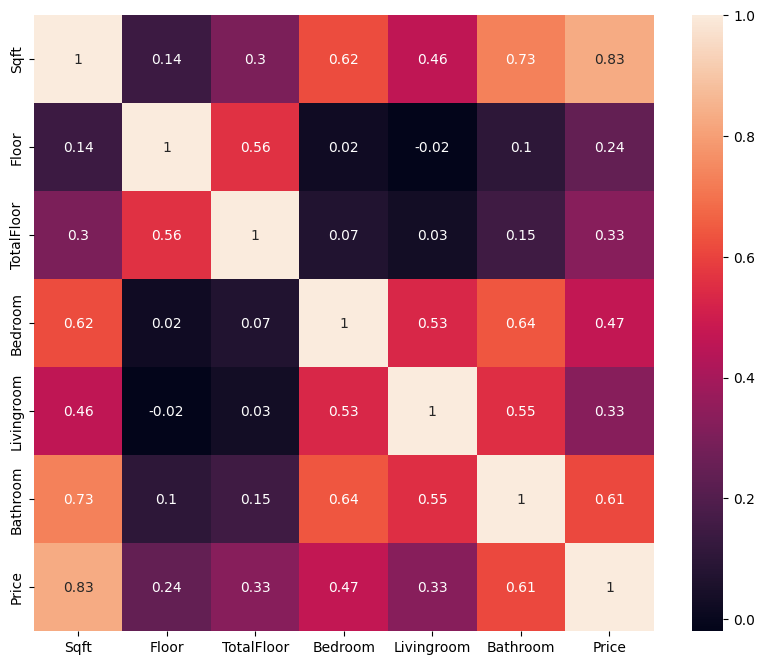

In [33]:
corr_mat = housedatadf.corr().round(2)

fix, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(data=corr_mat, annot = True, ax=ax)

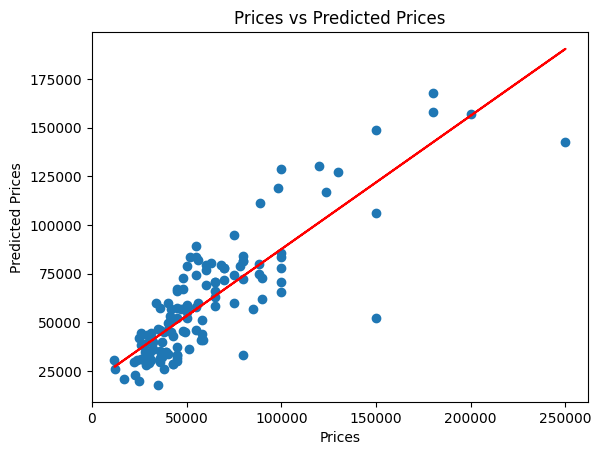

In [35]:
from numpy.polynomial import Polynomial

fig, ax1 = plt.subplots()
ax1.scatter(y_test, pred_y)

#Fir polynomial (degree 1 = linear)
p = Polynomial.fit(y_test, pred_y,deg = 1)

ax1.plot(y_test, p(y_test), color='red')
ax1.set_xlabel("Prices")
ax1.set_ylabel("Predicted Prices")
ax1.set_title("Prices vs Predicted Prices")
plt.show()


In [22]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [23]:
pred = lr.predict(X_test)

In [36]:
# MAE measures the average absolute difference between actual and predicted values.
# Use when outliers should not dominate the metric

mean_absolute_error(y_pred = pred_y, y_true = y_test)

13545.889261601758

In [37]:
# MSE measures the average of the squared differences between actual and predicted values. 
# Use When large errors are very costly

mean_squared_error(y_pred=pred_y, y_true=y_test)

401487570.46258783

In [38]:
# R² measures how much variance in the target variable is explained by the model.
# Measures how well a statistical model predicts an outcome. 
# Value ranges from 0 to 1 
# The better a model is at making predictions, the closer its R² will be to 1. 
r2_score(y_pred=pred_y, y_true=y_test)

0.7202087278032021

// Iris Kmean Clustering

K Means is an unsupervised learning algorithm. That means:

We do NOT use the species labels
We only use the feature values
The goal is to group similar flowers together
K Means tries to:

Choose K centroids (here, K=3)
Assign each flower to the nearest centroid
Recompute centroids as the mean of assigned points
Repeat until centroids stop moving

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

iris = load_iris()
X = iris.data

#Create a DataFrame from the iris dataset
df = pd.DataFrame(X, columns=iris.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


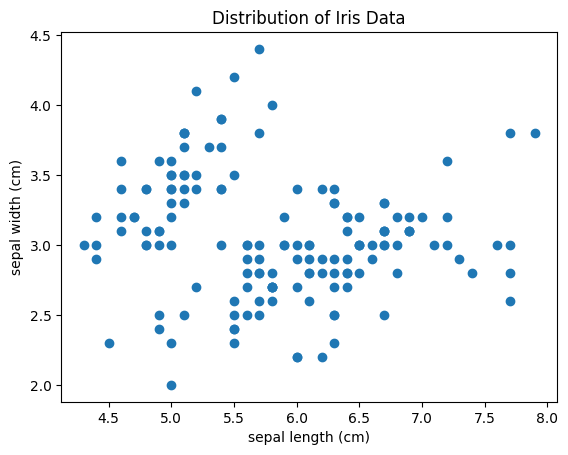

In [40]:
plt.scatter(X[:, 0], X[:, 1])
#plt.scatter(centroids[:, 0], centroids[:, 1], s=200, color='red')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('Distribution of Iris Data')
plt.show()

The silhouette score measures two things at once:

Cohesion: how close a point is to its own cluster
Separation: how far it is from the nearest other cluster
For a point i:

s(i)=(b(i)-a(i)) / (max⁡(a(i),b(i)))

Where: a(i) = average distance to points in the same cluster b(i) = average distance to points in the nearest other cluster Silhouette score is high when clusters are far apart, not when they are semantically correct

In [42]:
# identify optimal number of clusters using Silhouette score
# The Silhouette Coefficient is calculated using the mean intra-cluster distance (``a``) 
# and the mean nearest-cluster distance (``b``) for each sample

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k).fit(X)
    label = kmeans.labels_
    sc = silhouette_score(X, label)
    print(f"For k={k}, the Silhouette Score is {sc:.2f}")

For k=2, the Silhouette Score is 0.68
For k=3, the Silhouette Score is 0.55
For k=4, the Silhouette Score is 0.50
For k=5, the Silhouette Score is 0.49
For k=6, the Silhouette Score is 0.46
For k=7, the Silhouette Score is 0.32
For k=8, the Silhouette Score is 0.34
For k=9, the Silhouette Score is 0.34
For k=10, the Silhouette Score is 0.31


In [ ]:
# Elbow Method
# Inertia - wcss (within cluster sum of squares) stores the sum of squared distances of points to their closest cluster 
inertia = []

# Try different values of k
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    # inertia calculates sum of square distance in each cluster

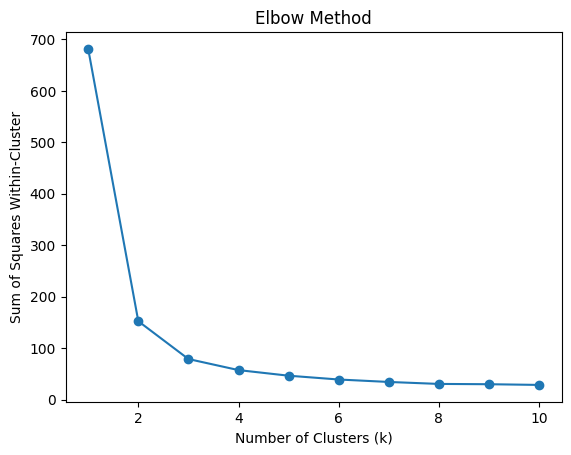

In [44]:
# The “elbow” is the point where: Adding more clusters gives only marginal improvement

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squares Within-Cluster')
plt.title('Elbow Method')
plt.show()

In [45]:
#Perform k-means clustering

k=3 # number of clusters
kmeans =KMeans(n_clusters=k, n_init='auto', random_state=42)
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [46]:
#Get the cluster labels and centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

#Add the cluster labels to the DataFrame
df['Cluster'] = labels

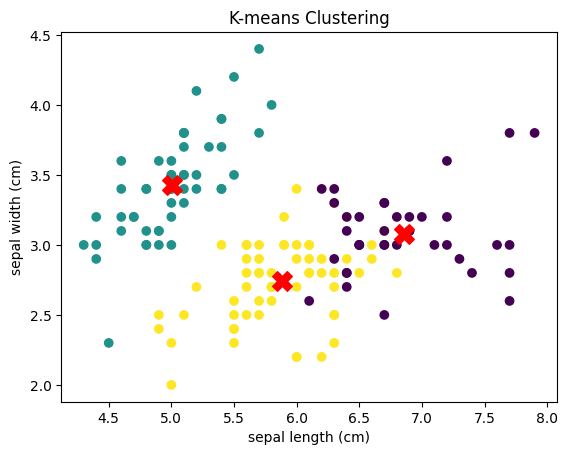

In [47]:
# Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, color='red')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('K-means Clustering')
plt.show()

In [48]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
